




# Projet Fil Rouge 2026 : Reconnaissance de commandes audio


**Noms :**

**Prénoms :**

**Nom du binôme :**




Ces 12 séances de TP vont vous permettre de tester l'algorithme de programmation dynamique vu en CTD puis de réaliser la mise en oeuvre d'un système de reconnaissance audio de mots isolés (constituant des
commandes pour les drones).

<img src="files/DroneJS.JPG" width="600" height="500"  >



Ces séances se décomposent en ces parties : 
- Partie I : Prétraitement des données 
- Partie II : Sélection de variables et pénalisation
- Partie III : Classification par méthodes à noyau 
- Partie IV : Apprentissage par ensemble : Adaboost, gradient boosting
- Partie V : Classification par réseaux de neurones
- Partie VI : Votre étude




In [37]:
!pip3.12 install librosa


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sklearn
import math
import numpy.random as rnd
import seaborn as sns
import librosa
from os import listdir
from os.path import isfile, join
import glob
import re
import torch

# On fixe la seed pour tout le projet pour la reproductibilité des résultats
RANDOM_SEED = 51
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# Preprocessing

Sur l'espace moodle, vous trouverez un dossier d'enregistrements audio de mots de commandes pour un drone quadricoptère constitués de plusieurs locuteurs masculins (notés M01..M13) et locutrice féminines (F01..F05) pour quelques commandes. 


In [39]:
data = [] 
label = [] 
genres = []
min_duration = None
words = ['avance','recule','tournegauche']
list_genres = ['M', 'F']

for file_name in glob.glob('FichierTest/*.wav'):
    record = librosa.load(file_name)[0]
    data.append(record)
    # Computation of the minimal size of recordings
    if min_duration is None or record.shape[0] < min_duration:
        min_duration = record.shape[0] 
    
    # Creation of the vector of label
    for i, word in enumerate(words):
        if re.search(word, file_name):
            label.append(i)

    # Creation of the vector of label
    for i, genre in enumerate(list_genres):
        if re.search(genre, file_name[12:]):# 12 is for ignoring "FichierTest/"
            genres.append(genre)

fs = librosa.load(file_name)[1] # Sampling frequency
genres = np.array(genres)
print(f'The smallest record contains {min_duration} samples, and the sample frequency is {fs} Hz')


The smallest record contains 18522 samples, and the sample frequency is 22050 Hz


### We trim the recordings to isolate the word and have identical durations
The smallest record contains 18 522 samples. We are going to cut all recordings to be of this size.

In [40]:
def trim(record):
    half_duration = 18522//2

    # First, we compute the barycenter of energy along time. We interpret it as the moment when the word appears
    barycenter = int(np.floor(np.multiply(np.power(record,2),np.arange(0,record.shape[0],1)).sum()/np.power(record,2).sum()))

    # Second, we adjust the barycenter to be in the index range
    if barycenter-half_duration < 0:
        barycenter += half_duration-barycenter
    if barycenter+half_duration >= record.shape[0]:
        barycenter -= barycenter+half_duration - record.shape[0]
    
    # Finally, we trim the recording around the barycenter 
    return record[barycenter-half_duration:barycenter+half_duration]

In [41]:
X = np.empty((len(data),min_duration))
for i in range(len(data)):
    X[i,:] = trim(data[i])

y = np.array(label)
print(f'Shape of inputs X is {X.shape} and size of targets class is {y.shape}')

Shape of inputs X is (54, 18522) and size of targets class is (54,)


### Spectral representation

1. Apply a Fourier transform on the signals in $X$ using the function fft of scipy. Explain why the resulting dimension is too large to apply logistic regression.

2. Let $\hat{X}$ be the Fourier transform of $X$. Apply a PCA on $|\hat{X}|$ and plot the total explained variance in function of the numer of components.

In [42]:
from scipy import signal
from scipy.fft import fft
from sklearn.decomposition import PCA



In [43]:
x_hat = fft(X)

1. La dimension est trop grande car on a beaucoup trop de variable par rapport au nombre d'observations. Ainsi le model va overfitter, et ne va pas généraliser 

2. PCA on $|\hat{X}|$ :

Text(0, 0.5, 'Variance expliquée cumulée')

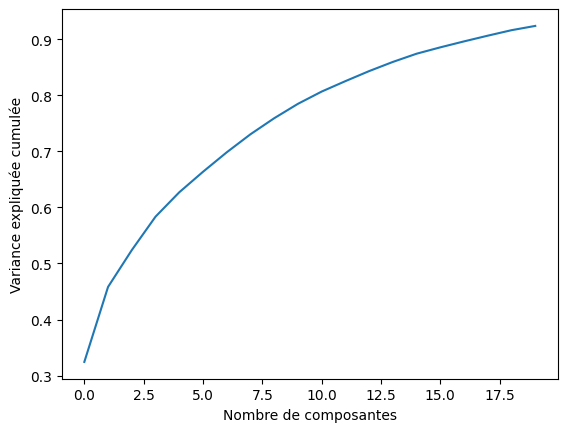

In [44]:
pca = PCA(n_components=20).fit(np.abs(x_hat)) # On fit sur les 20 premières components, pour la suite.
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')

3. Apply a Short Term Fourier Transform on $X$. What are the dimension of stft $\hat{X}[t,f]$?

4. Make 2 subplots (3x3) of the stft (as images with function .imshow()) with three instances of each words, one for male and one for female 

3.  SFTT on $|{X}|$:

In [45]:
from scipy.signal import stft

# On choisit des paramètres standard (fenêtre de 256 ou 512 points)
nperseg = 400  # Environ 18ms à 22kHz, typique pour la parole
f, t, Zxx = stft(X, fs=fs, nperseg=nperseg)

print(f"Dimensions de la STFT (Zxx) : {Zxx.shape}")
# Zxx.shape[0] = nombre d'échantillons (54)
# Zxx.shape[1] = nombre de fréquences (f)
# Zxx.shape[2] = nombre de segments temporels (t)

Dimensions de la STFT (Zxx) : (54, 201, 94)


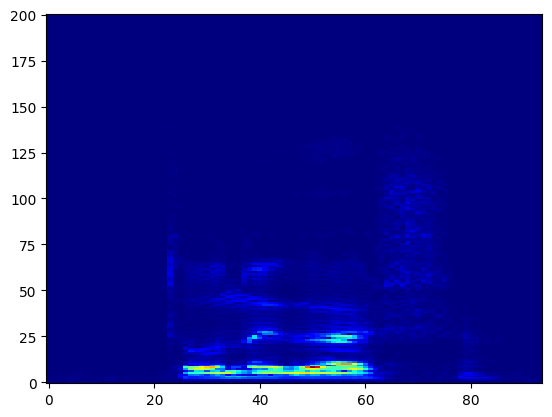

In [46]:
img = plt.imshow(abs(Zxx[0,:,:]), origin='lower', cmap='jet', interpolation='nearest', aspect='auto')
plt.show() # TODO utile ou pas ? 

4. On définit une fonction générique qui pour 3 instances de chaque mot, pour chaque sexe, affiche ces subplots en fonction d'une méthode pour : d'abord STFT, puis on l'utilisera aussi pour la MFCC.

In [47]:
words = ['avance', 'recule', 'tournegauche']
list_genres = ['M', 'F']

def show_subplots_for_transformed_data(transformed_data, method="stft"):
    for genre in list_genres:
        # On crée une nouvelle figure 3x3 pour chaque genre
        fig, axs = plt.subplots(3, 3, figsize=(15, 10))
        fig.suptitle(f'Spectrogrammes pour le genre : {genre}')
        
        for i, word_label in enumerate(range(3)): # Lignes (les 3 mots)
            # On trouve tous les indices correspondants (ex: tous les 'M' qui disent 'avance')
            indices = np.where((y == word_label) & (genres == genre))[0]
            
            # On prend les 3 premières instances trouvées pour remplir les 3 colonnes
            for j in range(3): 
                idx_to_plot = indices[j]
                ax = axs[i, j] # On cible la case (ligne i, colonne j)
                
                # En fonction de la méthode, on applique un post process différent:

                if method=="stft":
                    # Calcul de la magnitude en log pour voir les détails
                    spec_data = np.abs(transformed_data[idx_to_plot])
                    # On utilise ax.imshow pour dessiner DANS la case précise
                    im = ax.imshow(20 * np.log10(spec_data + 1e-10), 
                                origin='lower', aspect='auto', cmap='jet')
                
                if method=="mfcc":
                    ax = axs[i, j]
            
                    # Utilisation de la fonction spécialisée de librosa pour l'affichage
                    img = librosa.display.specshow(X_mfcc[idx_to_plot], 
                                                sr=fs, 
                                                ax=ax, 
                                                x_axis='time')
                    
                    # On ajoute des labels pour la clarté
                    if j == 0: ax.set_ylabel(f"{words[word_label]}\nCoefficients")
                    if i == 0: ax.set_title(f"Instance {j+1}")
                    
                # Habillage (optionnel mais recommandé)
                if j == 0: ax.set_ylabel(words[word_label])
                if i == 0: ax.set_title(f"Instance {j+1}")

    plt.tight_layout()
    plt.show()


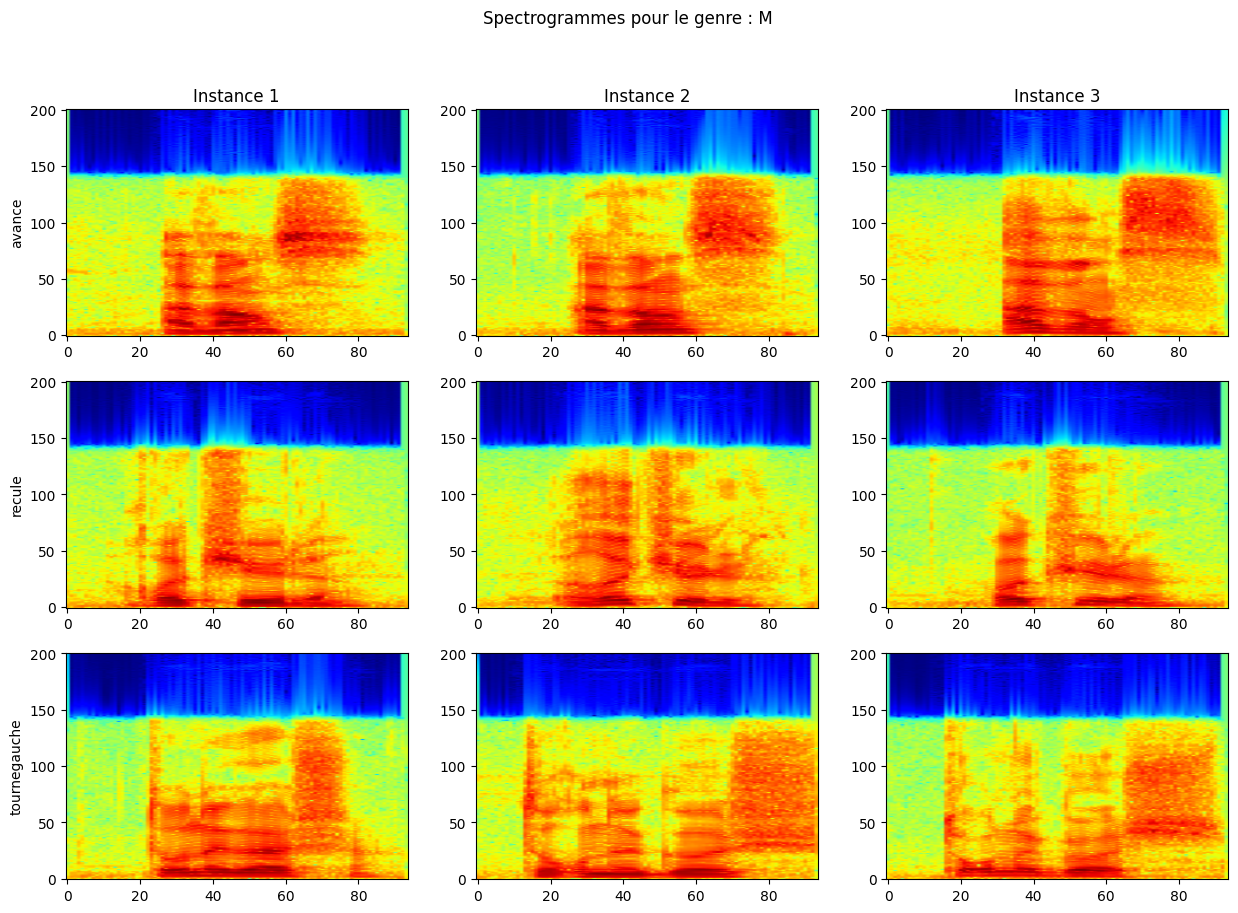

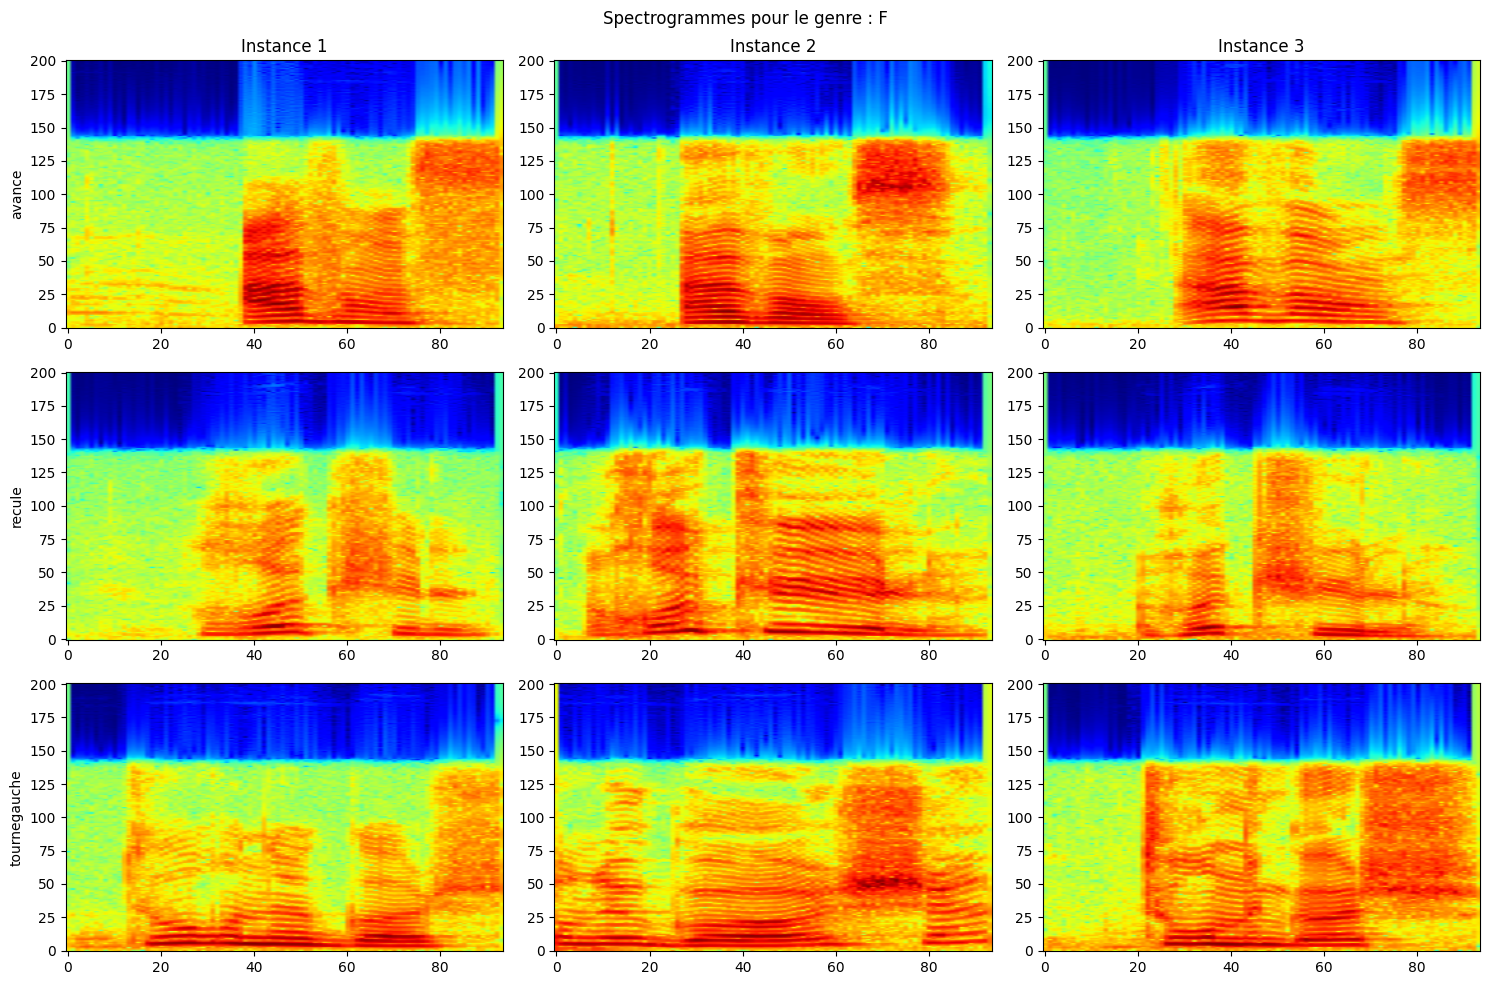

In [48]:
show_subplots_for_transformed_data(Zxx, method="stft")

### MFCC (Mel-Frequency Cepstral Coefficients)

1. Compute the MFCC of the signals in $X$ using the librosa library.

2. As for Short Term Fourier Transform, plot the computed coefficients over time of three instances of each word, one male and one for female 

1. MFCC sur $X$ :

In [49]:
n_mfcc = 13  # Valeur standard en reconnaissance vocale
mfccs = []

for i in range(X.shape[0]):
    # Calcul des MFCC pour chaque ligne de X
    # On précise la fréquence d'échantillonnage fs calculée précédemment
    mfcc = librosa.feature.mfcc(y=X[i, :], sr=fs, n_mfcc=n_mfcc)
    mfccs.append(mfcc)

# Conversion en tableau numpy
# La forme sera (nb_echantillons, n_mfcc, nb_frames_temporelles)
X_mfcc = np.array(mfccs)

print(f"Forme des MFCC : {X_mfcc.shape}")

Forme des MFCC : (54, 13, 37)


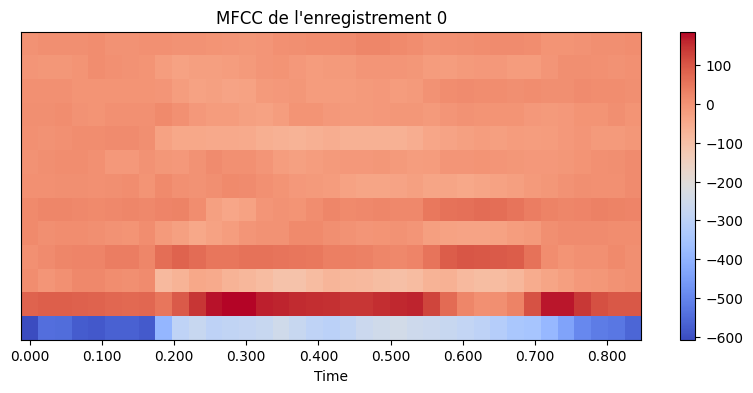

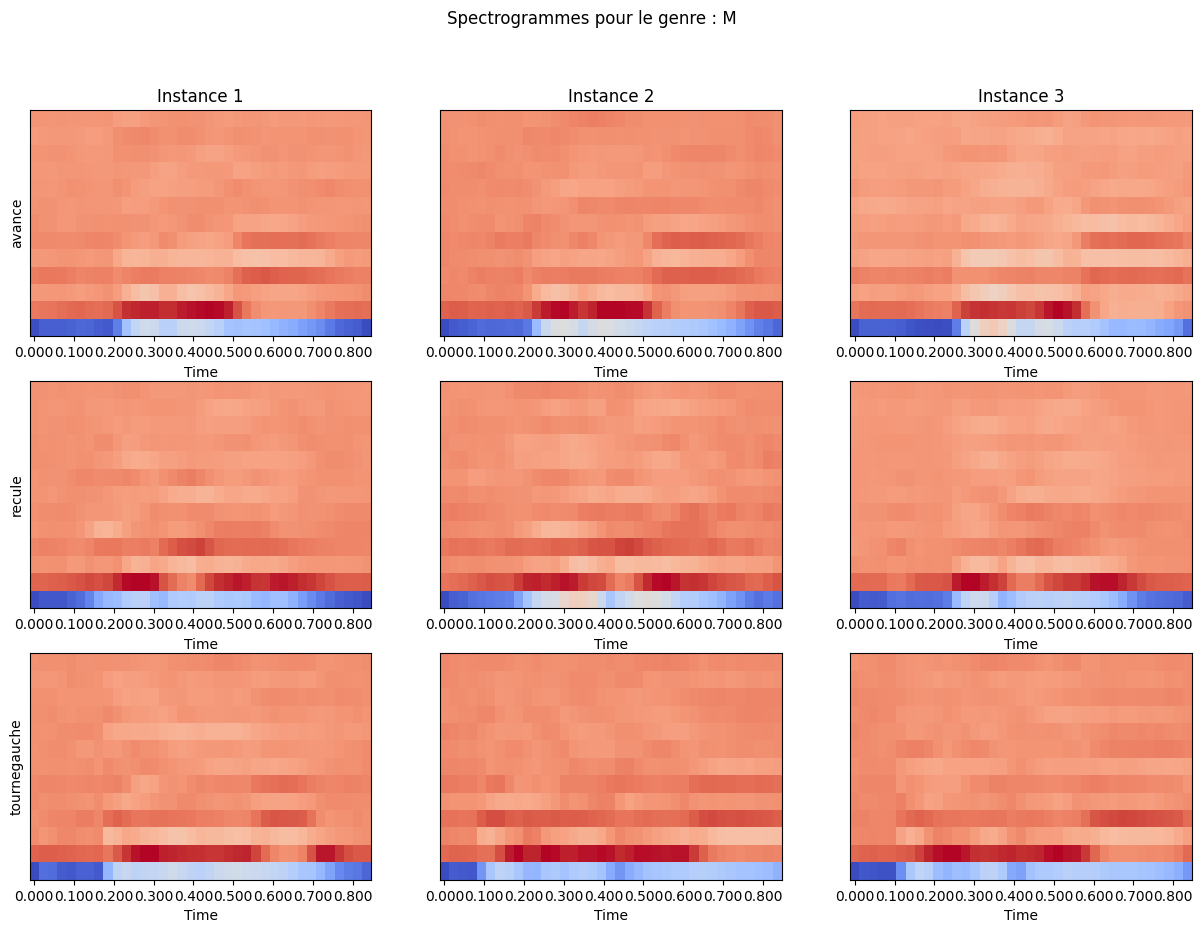

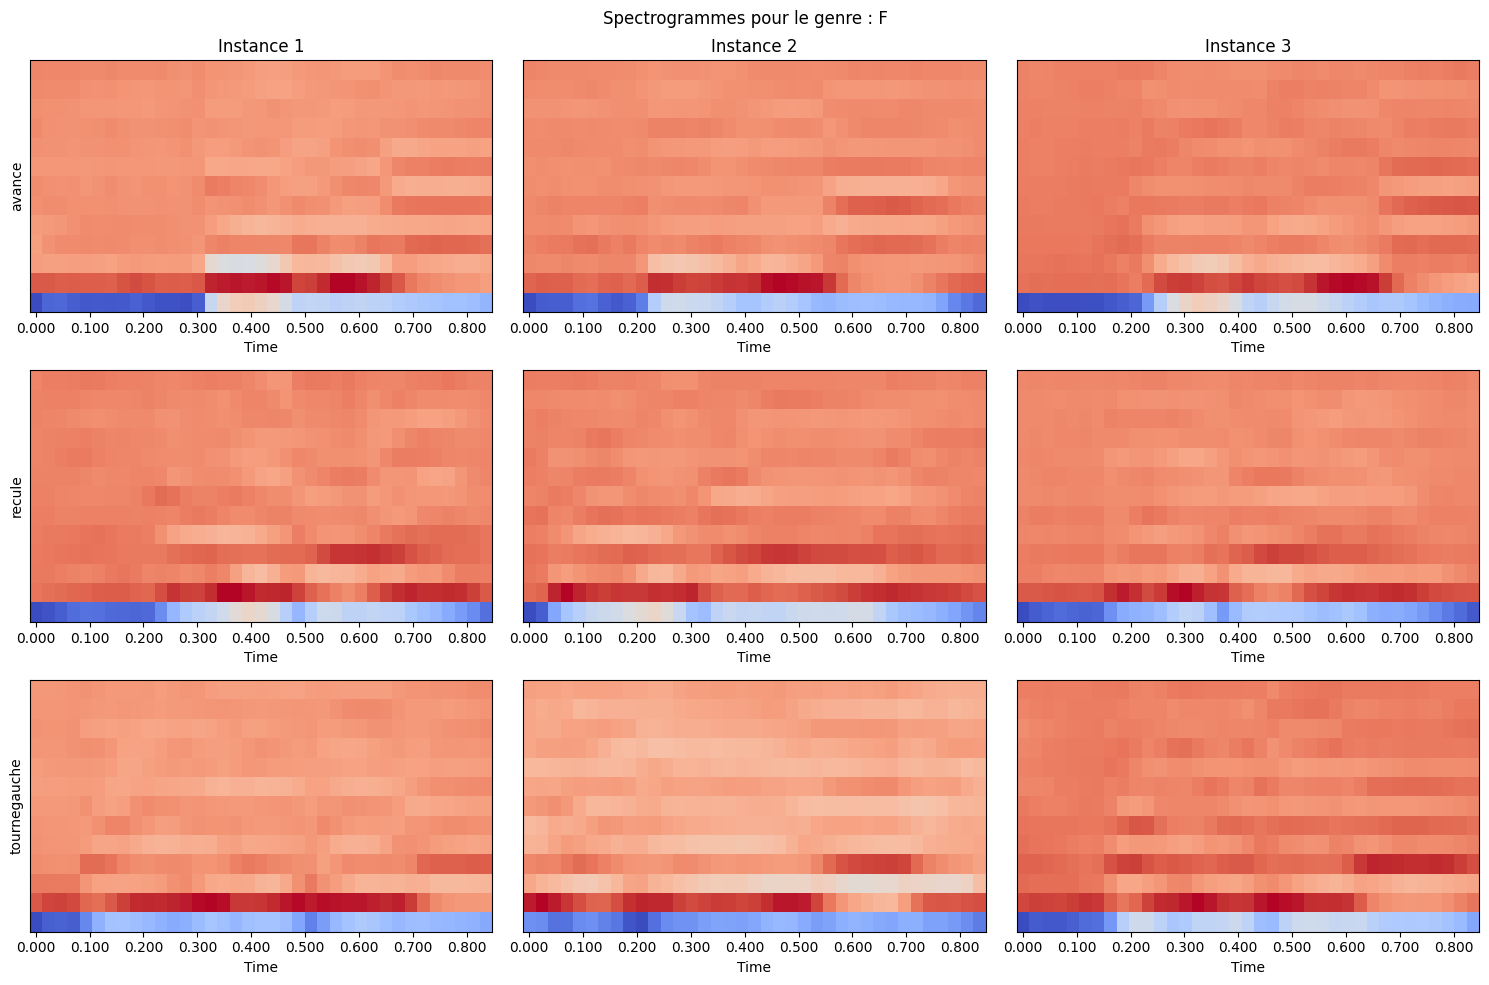

In [50]:
import librosa.display

# 1. MFCC sur X
plt.figure(figsize=(10, 4))
librosa.display.specshow(X_mfcc[0], x_axis='time', sr=fs)
plt.colorbar()
plt.title('MFCC de l\'enregistrement 0')
plt.show() # TODO: eske afficher image utile ?

# 2. Affichage des subplots
show_subplots_for_transformed_data(X_mfcc, method="mfcc")

#### Now we will build sklearn transformers to extract features

Create a class STFT in the same spirit as FFT. 
Add a first argument to choose between returning different statistics (mean and max over the rows) along time. Add a second argument that gives the maximum frequency index.
   
Likewise, create a class MFCC as just before, define a first agument to choose between returning different statistics (mean and max over the rows) along time and another one to select the number of coefficients.

In [51]:
from sklearn.base import BaseEstimator, TransformerMixin

In [52]:
class FFT(BaseEstimator, TransformerMixin):
    def __init__(self, idx_frequence_max=None):
        self.idx_frequence_max = idx_frequence_max
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        # Perform arbitary transformation        
        return np.absolute(fft(X)[:self.idx_frequence_max])

In [53]:
class STFT(BaseEstimator, TransformerMixin):
    def __init__(self, stat="mean", idx_frequence_max=None):
        self.stat = stat
        self.idx_frequence_max = idx_frequence_max
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        # Perform arbitary transformation   
        f, t, Zxx = signal.stft(X, fs=22050)
        Zxx_abs = np.abs(Zxx)

        # Agrégation statistique le long de l'axe du temps (axe 2)
        if self.stat == 'mean':
            return np.mean(Zxx_abs, axis=2)
        elif self.stat == 'max':
            return np.max(Zxx_abs, axis=2)
        else:
            raise ValueError("stat doit être 'mean' ou 'max'")


In [54]:
class MFCC(BaseEstimator, TransformerMixin):
    def __init__(self, stat='mean', n_mfcc=13):
        self.stat = stat
        self.n_mfcc = n_mfcc
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X, y=None):
        features = []
        for i in range(X.shape[0]):
            # Calcul des MFCC : shape (n_mfcc, n_time)
            m = librosa.feature.mfcc(y=X[i, :], sr=22050, n_mfcc=self.n_mfcc)
            
            # Agrégation selon la statistique choisie sur l'axe du temps (axe 1 ici)
            if self.stat == 'mean':
                features.append(np.mean(m, axis=1))
            elif self.stat == 'max':
                features.append(np.max(m, axis=1))
                
        return np.array(features)

#### From Part I to Part IV, **FFT + PCA** will be exclusively used as the prepocessing method.

# Partie I : Multiclass regression


Apply a **multiclass regression** model.

We model the probabilities by the following form :

$$
\mathbb{P}(Y_i = j) = \frac { \exp^{-\beta_j^{T} X_i } } {1 + \sum_{\ell = 1}^{K-1} \exp^{-\beta_\ell^{T} X_i }}, 
$$
For all $j$ in $\{ 1,2, \dots , K-1 \}$.





In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

First, split your dataset into a training (80%) and a test (20%) set using sklearn.


In [56]:

# Notre jeu de donnée est la FFT des individus, projetée dans un espace de plus faible dimension
# Pour ça on prend la matrice des données FFT x_hat, on split (pr éviter le data leakage), puis on projete les 
# individus dans l'espace de la PCA avec fit_transform

# On split
X_abs = np.abs(x_hat)  # shape (54, 18522)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_abs, y,
    test_size=0.20,
    random_state=RANDOM_SEED,   # 51 comme le RICARD
    stratify=y         # Important pour les petits datasets
)

# 2. On fit la PCA UNIQUEMENT sur le train
pca = PCA(n_components=20)
X_train = pca.fit_transform(X_train_raw)   # fit + transform sur le train
X_test  = pca.transform(X_test_raw)        # transform uniquement sur le test

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")



Train size: 43 | Test size: 11


Without using Pipeline from sklearn.pipeline, perform leave one out cross validation manually on your training set by hand using a logistic regression classifier **LogisticRegression** from sklearn.linear_model. Prepocess each fold using FFT + PCA choosing the first 20 principal components before using the classifier. Report the result for each fold and the average performance across all folds.

In [57]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def loo_cv(X_raw, y, idx_frequence_max, n_components, C, verbose=False):
    y_arr = np.array(y)
    n = X_raw.shape[0]
    fold_accuracies = []
    for i in range(n):
        # Split du fold
        X_fold = np.delete(X_raw, i, axis=0)
        X_val  = X_raw[i:i+1]
        y_fold = np.delete(y_arr, i)
        y_val  = y_arr[i:i+1]
        X_fold_f = X_fold[:, :idx_frequence_max]
        X_val_f  = X_val[:,  :idx_frequence_max]

        # fit PCA  UNIQUEMENT sur le fold train
        n_eff = min(n_components, X_fold_f.shape[0], X_fold_f.shape[1])
        pca_fold = PCA(n_components=n_eff)
        X_fold_p = pca_fold.fit_transform(X_fold_f)
        X_val_p  = pca_fold.transform(X_val_f)

        # Train + predict
        model = LogisticRegression(C=C, max_iter=1000)
        model.fit(X_fold_p, y_fold)
        acc = accuracy_score(y_val, model.predict(X_val_p))
        fold_accuracies.append(acc)
        if verbose:
            print(f"Fold {i+1}: Accuracy = {acc:.1f}")
    avg = np.mean(fold_accuracies)
    if verbose:
        print(f"\nAverage Performance across all folds: {avg:.4f}")
    return avg

# Résultat:
loo_cv(X_train_raw, y_train, idx_frequence_max=9261, n_components=20, C=1.0, verbose=True)


Fold 1: Accuracy = 1.0
Fold 2: Accuracy = 0.0
Fold 3: Accuracy = 1.0
Fold 4: Accuracy = 1.0
Fold 5: Accuracy = 0.0
Fold 6: Accuracy = 1.0
Fold 7: Accuracy = 0.0
Fold 8: Accuracy = 1.0
Fold 9: Accuracy = 1.0
Fold 10: Accuracy = 1.0
Fold 11: Accuracy = 1.0
Fold 12: Accuracy = 1.0
Fold 13: Accuracy = 1.0
Fold 14: Accuracy = 1.0
Fold 15: Accuracy = 0.0
Fold 16: Accuracy = 1.0
Fold 17: Accuracy = 1.0
Fold 18: Accuracy = 1.0
Fold 19: Accuracy = 0.0
Fold 20: Accuracy = 1.0
Fold 21: Accuracy = 0.0
Fold 22: Accuracy = 1.0
Fold 23: Accuracy = 1.0
Fold 24: Accuracy = 1.0
Fold 25: Accuracy = 1.0
Fold 26: Accuracy = 1.0
Fold 27: Accuracy = 1.0
Fold 28: Accuracy = 1.0
Fold 29: Accuracy = 0.0
Fold 30: Accuracy = 1.0
Fold 31: Accuracy = 0.0
Fold 32: Accuracy = 1.0
Fold 33: Accuracy = 0.0
Fold 34: Accuracy = 0.0
Fold 35: Accuracy = 1.0
Fold 36: Accuracy = 1.0
Fold 37: Accuracy = 1.0
Fold 38: Accuracy = 0.0
Fold 39: Accuracy = 1.0
Fold 40: Accuracy = 1.0
Fold 41: Accuracy = 1.0
Fold 42: Accuracy = 1.0
F

np.float64(0.7441860465116279)

Why don't we preprocess the whole training set before performing the cross validation ?

> Parce que l'ACP se base sur l'ensemble du jeu de donnée, y compris celles qui auraient fini dans le jeu de test.
 En preprocessant avant et splittant après, le dataset d'entraînement contiendrait de l'information du set de test, encodée dans les composantes principales de l'ACP. On biaiserait alors toute évaluation du modèle. En splittant après, on s'assure que les deux jeux de données restent bien séparés.

Perform a grid search by hand on the training set over the prepocessing (idx_frequence_max + principal components) and logistic regression (C) parameters. Return the best parameters along with the score. Test your best model on your test set and give the score.

**Note:** In the following, the parameters to be tuned are **idx_frequence_max** and **the number of principal components** for FFT + PCA, and the regularization coefficient **C** for the logistic regression classifier. 

In [58]:
# Grille des hyperparamètres
idx_freq_values = [100] #, 500, 1000, 3000, 9261]
n_comp_values   = [5] # , 10, 20, 30]
C_values        = [0.01] #, 0.1, 1, 10, 100]

best_score  = -1
best_params = {}

for idx_freq in idx_freq_values:
    for n_comp in n_comp_values:
        for C in C_values:
            score = loo_cv(X_train_raw, y_train,
                           idx_frequence_max=idx_freq,
                           n_components=n_comp,
                           C=C,
                           verbose=False)
            if score > best_score:
                best_score  = score
                best_params = {'idx_frequence_max': idx_freq, 'n_components': n_comp, 'C': C}

print(f"Meilleurs paramètres : {best_params}")
print(f"Meilleur score LOO   : {best_score:.4f}")

# Test du meilleur modèle sur le test set
idx_freq = best_params['idx_frequence_max']
n_comp   = best_params['n_components']
C        = best_params['C']

pca_best = PCA(n_components=n_comp)
X_train_p = pca_best.fit_transform(X_train_raw[:, :idx_freq])
X_test_p  = pca_best.transform(X_test_raw[:,  :idx_freq])

best_model = LogisticRegression(C=C, max_iter=1000)
best_model.fit(X_train_p, y_train)

print(f"\nScore sur le test set : {accuracy_score(y_test, best_model.predict(X_test_p)):.4f}")
# Meilleurs paramètres : 
# {'idx_frequence_max': 3000, 'n_components': 20, 'C': 10}
# Meilleur score LOO   : 0.7907
# Score sur le test set : 0.6364

Meilleurs paramètres : {'idx_frequence_max': 100, 'n_components': 5, 'C': 0.01}
Meilleur score LOO   : 0.2558

Score sur le test set : 0.2727


Use the **Pipeline** of sklearn to wrap the preprocessing and the classifier altogether. Then apply **GridSearchCV** to perform a grid search with cross-validation in order to tune the preprocessing and classifier parameters. Use **LeaveOneOut()** to perform leave one out cross-validation.
You can access to all results with "cv_results_".

In [59]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.pipeline import Pipeline

#  Pipeline : FFT > PCA > LR
pipeline = Pipeline([
    ('fft', FFT()),
    ('pca', PCA()),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = {
    'fft__idx_frequence_max': idx_freq_values,
    'pca__n_components':      n_comp_values,
    'clf__C':                 C_values
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=LeaveOneOut(),
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_raw, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score LOO   : {grid_search.best_score_:.4f}")
print(f"Score sur le test set: {grid_search.score(X_test_raw, y_test):.4f}")

cv_results_ = grid_search.cv_results_


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

Meilleurs paramètres : {'clf__C': 0.01, 'fft__idx_frequence_max': 100, 'pca__n_components': 5}
Meilleur score LOO   : 0.6744
Score sur le test set: 0.7273


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Evaluation of results

Evaluate the result by confusion matrix and percentage of correct classification, first on the training set and then on the test set.

*Tip:* Remember to put a function to display the confusion matrix

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
# Helper pour afficher la matrice de confusion
def plot_confusion_matrix(y_true, y_pred, title, ax=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=words)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    if ax:
        ax.set_title(title)
    else:
        plt.title(title)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

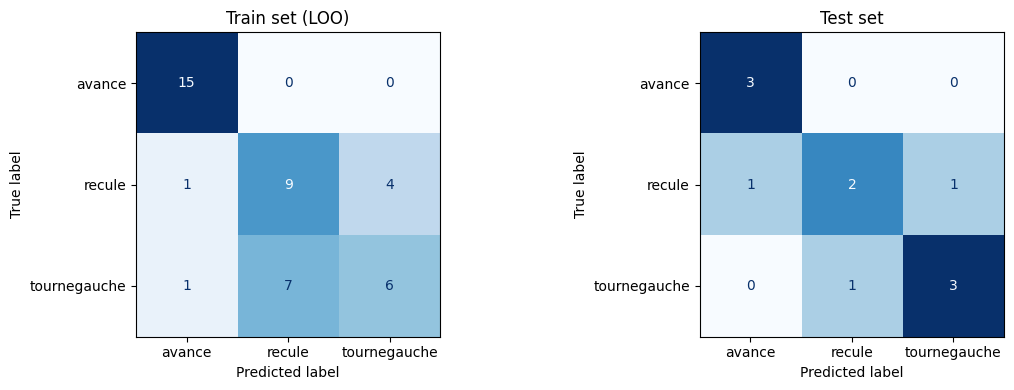

In [61]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from sklearn.model_selection import cross_val_predict

# Prédictions out-of-fold sur le GT (LOO honest)
y_train_oof = cross_val_predict(
    grid_search.best_estimator_,
    X_train_raw, y_train,
    cv=LeaveOneOut()
)

# Prédictions sur le test
y_test_pred = grid_search.predict(X_test_raw)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_confusion_matrix(y_train, y_train_oof, "Train set (LOO)", ax=axes[0])
plot_confusion_matrix(y_test,  y_test_pred, "Test set",        ax=axes[1])
plt.tight_layout()
plt.show()



Add **StandardScaler** in the preprocessing step and report if the performance is improved (confusion matrix and accuracy score).

**Note:** In the following, add **StandardScaler** in the preprocessing part using **Pipeline**.

Meilleurs params : {'clf__C': 0.01, 'fft__idx_frequence_max': 100, 'pca__n_components': 5}
Meilleur score LOO   : 0.3023  (sans scaler: 0.6744)
Score sur le test set: 0.4545  (sans scaler: 0.7273)


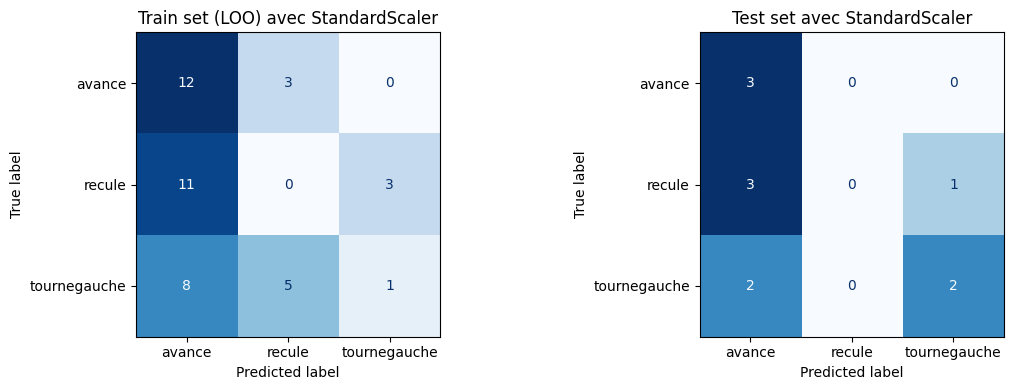

In [62]:
from sklearn.preprocessing import StandardScaler

# ON ajoute StandcardScaler à la pipeline
pipeline_scaled = Pipeline([
    ('fft', FFT()),
    ('pca', PCA()),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

grid_search_scaled = GridSearchCV(
    pipeline_scaled,
    param_grid,
    cv=LeaveOneOut(),
    scoring='accuracy',
    n_jobs=-1
)

grid_search_scaled.fit(X_train_raw, y_train)

print(f"Meilleurs params : {grid_search_scaled.best_params_}")
print(f"Meilleur score LOO   : {grid_search_scaled.best_score_:.4f}  (sans scaler: {grid_search.best_score_:.4f})")
print(f"Score sur le test set: {grid_search_scaled.score(X_test_raw, y_test):.4f}  (sans scaler: {grid_search.score(X_test_raw, y_test):.4f})")

# Confusion matrices
y_train_oof_scaled = cross_val_predict(
    grid_search_scaled.best_estimator_,
    X_train_raw, y_train,
    cv=LeaveOneOut()
)
y_test_pred_scaled = grid_search_scaled.predict(X_test_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_confusion_matrix(y_train, y_train_oof_scaled, "Train set (LOO) avec StandardScaler", ax=axes[0])
plot_confusion_matrix(y_test,  y_test_pred_scaled,  "Test set avec StandardScaler",        ax=axes[1])
plt.tight_layout()
plt.show()


# Part II: Classification by kernel methods

**Reminder** Kernel methods consist of plunging the data into a space of Hilbert dimension $\mathcal{H}$ where the data can be separated linearly.

**Representation Theorem:** The solution of the infinite dimensional separation problem is contained in a finite dimensional vector subspace of $\mathcal{H}$

### 1. Perform a core SVM classification

As before, use **Pipeline** and **GridSearchCV** to perform the SVM classifiction. Use the kernel **rbf** and vary the regularization parameter **C** and the kernel coefficient **gamma** of the classifier. Report the result using the accuracy score and the confusion matrix.

Recherche des meilleurs paramètres pour le SVM (RBF)...

Meilleurs paramètres : {'clf__C': 0.1, 'clf__gamma': 0.001, 'fft__idx_frequence_max': 1000, 'pca__n_components': 10}
Meilleur score LOO   : 0.3023
Score sur le test set: 0.2727


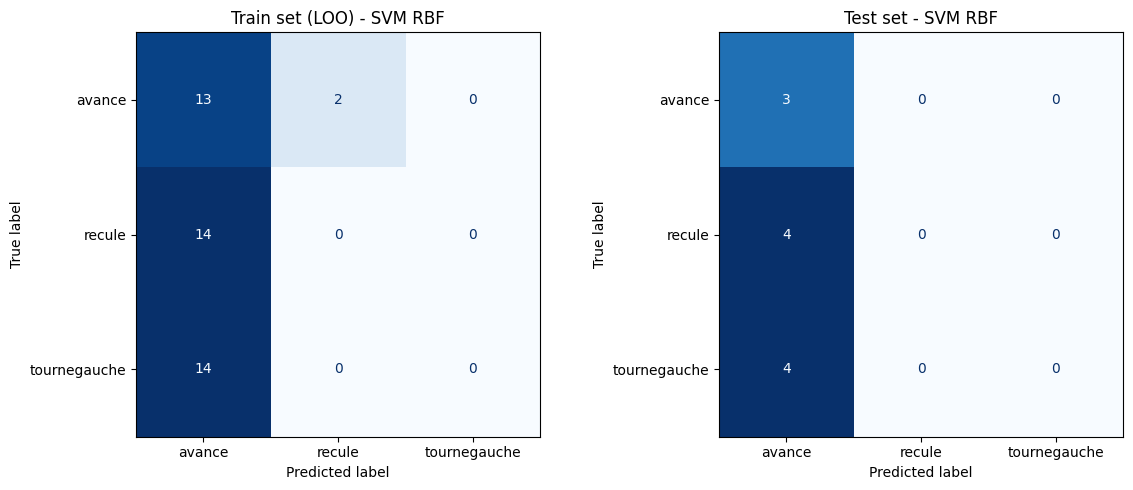

In [63]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_predict

#  Pipeline : FFT > PCA > Normalisation > SVM
pipeline_svm = Pipeline([
    ('fft', FFT()),
    ('pca', PCA()),
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf'))
])

param_grid_svm = {
    'fft__idx_frequence_max': [1000 ], # , 3000, 9261],
    'pca__n_components': [10 ], # , 20, 30],
    'clf__C': [0.1], #, 1, 10, 100],
    'clf__gamma': [0.001 ], #, 0.01, 0.1, 'scale']
}

grid_search_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=LeaveOneOut(),
    scoring='accuracy',
    n_jobs=-1
)

print("Recherche des meilleurs paramètres pour le SVM (RBF)...")
grid_search_svm.fit(X_train_raw, y_train)

# Affichage des res
print(f"\nMeilleurs paramètres : {grid_search_svm.best_params_}")
print(f"Meilleur score LOO   : {grid_search_svm.best_score_:.4f}")
print(f"Score sur le test set: {grid_search_svm.score(X_test_raw, y_test):.4f}")

# Evalution et reports du meilleur modèle
y_train_oof_svm = cross_val_predict(
    grid_search_svm.best_estimator_,
    X_train_raw, y_train,
    cv=LeaveOneOut()
)
y_test_pred_svm = grid_search_svm.predict(X_test_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion_matrix(y_train, y_train_oof_svm, "Train set (LOO) - SVM RBF", ax=axes[0])
plot_confusion_matrix(y_test, y_test_pred_svm, "Test set - SVM RBF", ax=axes[1])
plt.tight_layout()
plt.show()


#### Interprétations des résultats

On remarque que le modèle est globalement bon, notamment pour classer "avance".
Cependant montre une forte confusion entre "recule" et "tournegauche", notamment sur le test set. Cette baisse de précision suggère du surapprentissage, potentiellement du à la petite taille du dataset, malgré l'efficacité du noyau à séparer les données d'entraînement.



# Part III: Ensemble Method

## 1. Bootstrap Aggregation : Bagging

Boostrap consists in creating multiple data sets as follows. Suppose our
original data set consists of $N$ data points $X = \{x_1,..., x_N \}$. We can create a new
data set $X_B$ by drawing $N$ points at random from X, with replacement, so that some
points in $X$ may be replicated in $X_B$, whereas other points in $X$ may be absent from
$X_B$. This process can be repeated $L$ times to generate $L$ data sets each of size $N$ and
each obtained by sampling from the original data set $X$.

Consider a binary classification problem in which we are trying to predict the class, and suppose we generate $M$ bootstrap data sets and then use each to train a separate copy $y_m(x)$ of a classifier where $m = 1,...,M$. The committee prediction is given by voting with all $M$ models.

1. First you will transform $y$ in $y^1$ as follow
if $y = 1$, then $y^1 = 1$
if $y = 0$ or $y = 2$, then $y^1 = 0$.
Now we can apply binary classification. Since the label has changed, split your data as before (80-20) using **train_test_split**.

2. Code from scratch the Bagging of Decision trees with *max_depth = 2* only and compare the accuracy of the bagging model with the mean accuracy of the models and conclude. (the bootstrap is done on the training set with np.random.choice, and use $M=100$).

3. Apply Random Forest with *max_depth = 2* on the same problem and give the accuracy score. Is random Forest a Bagging model?



In [64]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [65]:
### 1. create y1

# "recule" : 1 ? 0
y1 = np.where(y == 1, 1, 0)

# Preprocess FFT et PCA (20 composantes) sur ce jeu là
X_abs = np.abs(fft(X))
pca_bagging = PCA(n_components=20)
X_pca = pca_bagging.fit_transform(X_abs)

# Split 80-20
X_train_bag, X_test_bag, y_train_bag, y_test_bag = train_test_split(
    X_pca, y1, 
    test_size=0.2, 
    random_state=RANDOM_SEED, 
    stratify=y1
)

print(f"Distribution y1 : {np.bincount(y1)}")


Distribution y1 : [36 18]


In [66]:
### 2. Bagging of decision from scratch

M = 100
n_samples = X_train_bag.shape[0]
models = []
individual_accuracies = []

# (Pour la reproductibilité)
rng = np.random.default_rng(RANDOM_SEED)

# On entraîne M modèles
for i in range(M):
    # Bootstrap : tirage avec remise
    indices = rng.choice(n_samples, size=n_samples, replace=True)

    X_boot, y_boot = X_train_bag[indices], y_train_bag[indices]
    
    # On entraîne un arbre (avec max_depth=2)
    tree = DecisionTreeClassifier(max_depth=2)
    tree.fit(X_boot, y_boot)
    models.append(tree)
    
    # Calcul du score individuel sur chaque test set
    individual_accuracies.append(accuracy_score(y_test_bag, tree.predict(X_test_bag)))

# Prédiction par vote majoritaire (Bagging)
predictions = np.array([model.predict(X_test_bag) for model in models])

# On fait la moyenne des prédictions (0 ou 1) puis on arrondit pour le vote majoritaire
y_pred_bagging = (predictions.mean(axis=0) >= 0.5).astype(int)

bagging_acc = accuracy_score(y_test_bag, y_pred_bagging)
mean_indiv_acc = np.mean(individual_accuracies)

print(f"Précision moyenne des arbres seuls : {mean_indiv_acc:.4f}")
print(f"Précision du modèle Bagging         : {bagging_acc:.4f}")

# Conclusion : TODO


Précision moyenne des arbres seuls : 0.6936
Précision du modèle Bagging         : 0.8182


In [67]:
### 3. Comparaison avec la version de scikit :

from sklearn.ensemble import RandomForestClassifier

# On instancie un RandomForestClassifier sur le même problèle
rf_model = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=RANDOM_SEED)
rf_model.fit(X_train_bag, y_train_bag)

rf_acc = rf_model.score(X_test_bag, y_test_bag)
print(f"Précision Random Forest : {rf_acc:.4f}")

# Réponse à la question : TODO


Précision Random Forest : 0.8182


## 2. Adaptative boosting : AdaBoost

Here is the algorithm Adaboost

1. Initialize the data weighting coefficients ${w_n}$ by setting $w_n^{(1)} = 1/N$ for $n = 1,...,N$.
2. For $m = 1,...,M$:
    
    **(a)** Fit a classifier $y_m(x)$ to the training data by minimizing the weighted
error function
    
$J_m = \sum_{n=1}^N{w_n^{(m)}I(y_m(x)\neq t_n)}$

where $I(y_m(x)\neq t_n)$ is the indicator function and equals $1$ when $y_m(x_n) 	= t_n$ and $0$ otherwise

**(b)** Evaluate the quantities

$\epsilon_m = \frac{\sum_{n=1}^N{w_n^{(m)}I(y_m(x)\neq t_n)}}{\sum_{n=1}^N{w_n^{(m)}}}$

and then use these to evaluate

$\alpha_m = \textit{ln}\left({\frac{1-\epsilon_m}{\epsilon_m}}\right)$

**(c)** Update the data weighting coefficients

$w_n^{(m+1)} = w_n^{(m)} \textit{exp}\left({\alpha_m I(y_m(x_n) \neq t_n)}\right)$

3. Make predictions using the final model, which is given by

    $Y_M(x) = \text{sign}\left(\sum_{m=1}^M {\alpha_m y_m(x)}\right)$


**Question 1 :** Code from scratch the Adaboost algorithm in the same configuration as Bagging in the previous section. Use the sklearn decision tree classifier with *max_depth = 2*. Compare its performances with Bagging.


In [68]:
y_train_ada = np.where(y_train_bag == 0, -1, 1)
y_test_ada = np.where(y_test_bag == 0, -1, 1)

N = X_train_bag.shape[0]
M = 100

# 1. Initialisation des poids
w = np.ones(N) / N

models_ada = []
alphas = []

for m in range(M):
    tree = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_SEED + m)
    tree.fit(X_train_bag, y_train_ada, sample_weight=w)
    y_pred_train = tree.predict(X_train_bag)
    I = (y_pred_train != y_train_ada).astype(int)
    epsilon_m = np.sum(w * I) / np.sum(w)
    
    # Sécurités numériques (pour éviter log(0) ou des poids négatifs)
    if epsilon_m == 0:
        alpha_m = 9.0 # Si l'arbre est bon, on lui donne un énorme poids
    elif epsilon_m >= 0.5:
        alpha_m = 0.0  # S'il est mauvais, on ignore
    else:
        alpha_m = np.log((1 - epsilon_m) / epsilon_m)
        
    # Etape C: maj poids
    w = w * np.exp(alpha_m * I)
    
    # On sauvegarde l'arbre et son poids
    models_ada.append(tree)
    alphas.append(alpha_m)

test_preds_accumulated = np.zeros(X_test_bag.shape[0])
for alpha_m, model in zip(alphas, models_ada):
    test_preds_accumulated += alpha_m * model.predict(X_test_bag)

y_pred_ada = np.sign(test_preds_accumulated)

adaboost_acc = accuracy_score(y_test_ada, y_pred_ada)

print(f"Précision du modèle Bagging (rappel)       : {bagging_acc:.4f}")
print(f"Précision du modèle AdaBoost 'from scratch': {adaboost_acc:.4f}")


Précision du modèle Bagging (rappel)       : 0.8182
Précision du modèle AdaBoost 'from scratch': 0.7273


Analyse des résultats: TODO

**Question 2 :** 
With sklearn library, apply adaboost with decision tree (*max_depth=2*) on the same problem. Find good parameters with the leave one out cross validation. Do the same thing with Gradient bossting.


In [69]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

cv = LeaveOneOut()

# 1. AdaBoost avec DecisionTree (max_depth=2)
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_SEED),
    random_state=RANDOM_SEED
)

param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(ada_clf, param_grid_ada, cv=cv, scoring='accuracy', n_jobs=-1)
grid_ada.fit(X_train_bag, y_train_bag)

print(f"Meilleurs paramètres AdaBoost : {grid_ada.best_params_}")
print(f"Précision Test AdaBoost       : {grid_ada.score(X_test_bag, y_test_bag):.4f}")

# 2. Gradient Boosting
gb_clf = GradientBoostingClassifier(
    max_depth=2, 
    random_state=RANDOM_SEED
)

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5]
}

grid_gb = GridSearchCV(gb_clf, param_grid_gb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train_bag, y_train_bag)

print(f"\nMeilleurs paramètres Gradient Boosting : {grid_gb.best_params_}")
print(f"Précision Test Gradient Boosting       : {grid_gb.score(X_test_bag, y_test_bag):.4f}")


Meilleurs paramètres AdaBoost : {'learning_rate': 0.1, 'n_estimators': 50}
Précision Test AdaBoost       : 0.9091

Meilleurs paramètres Gradient Boosting : {'learning_rate': 0.01, 'n_estimators': 200}
Précision Test Gradient Boosting       : 0.8182


# Partie IV : Neural Network with pytorch

Below we create torch tensor with the shape $(N,B,F)$, where
    
$N$ is the number of recordings in the set (train/test)

$B$ the size of batch, we choose $B=1$ because the dataset is really small

$F$ is the number of features

The tensors are converted to float type

The train set and test set constitute 50% of the initial dataset

**Transform X with your preprocessing**

In [70]:
import torch
### transform X with your preprocessing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5, random_state=RANDOM_SEED)
X_train = torch.tensor(X_train).reshape((X_train.shape[0],1,-1)).float()
X_test = torch.tensor(X_test).reshape((X_test.shape[0],1,-1)).float()
y_train = torch.nn.functional.one_hot(torch.tensor(y_train), num_classes=- 1).reshape((X_train.shape[0],1,-1)).float()
y_test = torch.nn.functional.one_hot(torch.tensor(y_test), num_classes=- 1).reshape((X_test.shape[0],1,-1)).float()

**Question 1:** : Create a model class (descending from torch.nn.Module). In a first time choose the appropriate architecture and the appropriate loss (the loss appear later) to reproduce logistic regression.

Usually a FNN is a succession of blocks (linear -> ReLU). Finally the networks transforms the initial vector into the output $\hat{y} \in \mathbb{R}^3, \hat{y}=(\mathbb{P}(y=0|x),\mathbb{P}(y=1|x),\mathbb{P}(y=2|x))$ where $y$ is the word we want to predict and $x \in \mathbb{R}^{18522}$ is the accoustic signal

    
    

In [71]:
from torch import nn
class NNClassification(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.network = torch.nn.Sequential(
            ### Define here the succession of torch.nn modules that will constitutes your network
            ### building blocks are torch.nn.ReLU, torch.nn.Linear
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )
    
    def forward(self, xb):
        ### the forward method will be called each time you will write model(x). 
        ### It's equivalent to the function predict of sklearn
        return self.network(xb)

In [72]:
model = NNClassification()
num_epochs = 10

result_test_loss = []
result_train_loss=[]

lr = 0.001
optimizer = torch.optim.Adam(model.parameters(),lr)
loss = ### What loss do you think is well suited for the classification problem (same as logistic regression)

for epoch in range(num_epochs):

    model.train()
    train_losses = []
    for i in range(X_train.shape[0]):
       ### code the training step (compute loss -> optimization step -> save the loss )
        
    model.eval()
    test_losses = []
    for i in range(X_test.shape[0]):
        ### code the eval step  (compute loss -> save the loss )

    result_train_loss.append(torch.stack(train_losses).mean().item())
    result_test_loss.append( torch.stack(test_losses).mean().item())
    



SyntaxError: invalid syntax (3320693820.py, line 9)

**Question 2:** Plot the train and test loss. What do you observe?

**Question 3 :** Compute the accuracy and plot the confusion matrix

**Question 4:** If you encounter overfitting try to regularize your model with Dropout and/or L2/L1 Regularization

**Question 5(Bonus)** : Create a CNN that takes in input the accoustic signal without preprocessing

# Bonus

Choose another preprocessing technique (**STFT** or **MFCC**) and perform Parts I to IV using this method. When applicable, the parameters to be tuned for STFT are the statistic (mean or max) and the maximum frequency index, while for MFCC, the parameters are the statistic and the number of coefficients.

# Partie V : Votre étude 




Réalisez votre propre étude par binôme :
- en modifiant les bases de test et/ou d'apprentissage c'est-à-dire en créant  votre propre base d'apprentissage et votre base de test à partir du corpus et des voix et bruits que vous aurez enregistrés
- en rajoutant davantage de classes (jusqu'à 13 ordres vocaux disponibles) 
- en utilisant d'autres méthodes de réduction de dimension (t-SNE...)
le tout en testant les différentes approches et en interprétant les résultats, à synthétiser sur un rapport en pdf. 


**Paramètres pour enregistrements audio de vos voix perso:**

16 KHz, mono, 16 bits, format *.wav*